## Prophet Implementation ':\)'

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet
from tqdm.notebook import tqdm
from sklearn.metrics import mean_absolute_percentage_error, mean_absolute_error, mean_squared_error

pd.set_option('display.max_columns', None)

In [9]:
# ---------------------------------------------------------
# 1. Load Parquet & Isolate Client
# ---------------------------------------------------------
# Read the optimized parquet file using PyArrow
df_long = pd.read_parquet('../Datasets/processed_electricity_data.parquet', engine='pyarrow')

client_id = 'MT_001'

# Filter the long dataframe for JUST our target client
client_df = df_long[df_long['ClientID'] == client_id].copy()

# Prophet strict requirement: rename Date to 'ds' and Consumption to 'y'
client_df = client_df.rename(columns={'Date': 'ds', 'Consumption': 'y'})

# Sort chronologically just to be safe
client_df = client_df.sort_values('ds').reset_index(drop=True)


In [10]:
# ---------------------------------------------------------
# 2. Time Series Split (Holdout Set)
# ---------------------------------------------------------
# Slice off the last 5 rows for testing
train_df = client_df.iloc[:-5]
test_df = client_df.iloc[-5:]

In [11]:
# ---------------------------------------------------------
# 3. Model Training & RECURSIVE Forecasting (No Leakage)
# ---------------------------------------------------------
m = Prophet()
m.add_country_holidays(country_name='PT') 
m.add_regressor('Temp_National_Avg')
m.add_regressor('Lag_15min')
m.add_regressor('Lag_24h')
m.add_regressor('Rolling_Mean_4h')

m.fit(train_df)

future_steps = test_df[['ds', 'Temp_National_Avg']].copy().reset_index(drop=True)

# We will append our predictions to this list as we go
history_y = list(train_df['y'].values)


# List to hold our final, clean predictions
clean_predictions = []

# Loop through the 5 future periods one by one
for i in range(5):
    current_step = future_steps.iloc[[i]].copy()
    
    current_step['Lag_15min'] = history_y[-1] 
    current_step['Lag_24h'] = history_y[-96]             # 96 steps = 24 hours ago
    current_step['Rolling_Mean_4h'] = np.mean(history_y[-16:]) # Average of last 16 steps
    
    step_forecast = m.predict(current_step)
    yhat = step_forecast['yhat'].values[0]

    # Save the prediction
    clean_predictions.append(yhat)
    
    history_y.append(yhat)

17:14:31 - cmdstanpy - INFO - Chain [1] start processing
17:14:34 - cmdstanpy - INFO - Chain [1] done processing


In [12]:
# ---------------------------------------------------------
# 4. Evaluation (With Clean Data)
# ---------------------------------------------------------
y_true = test_df['y'].values
y_pred = np.array(clean_predictions)

mape = mean_absolute_percentage_error(y_true, y_pred)
mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))

print(f"Metrics for {client_id}:")
print(f"MAPE: {mape:.2%}")
print(f"MAE:  {mae:.2f} kW")
print(f"RMSE: {rmse:.2f} kW")

Metrics for MT_001:
MAPE: 36.16%
MAE:  0.82 kW
RMSE: 0.84 kW


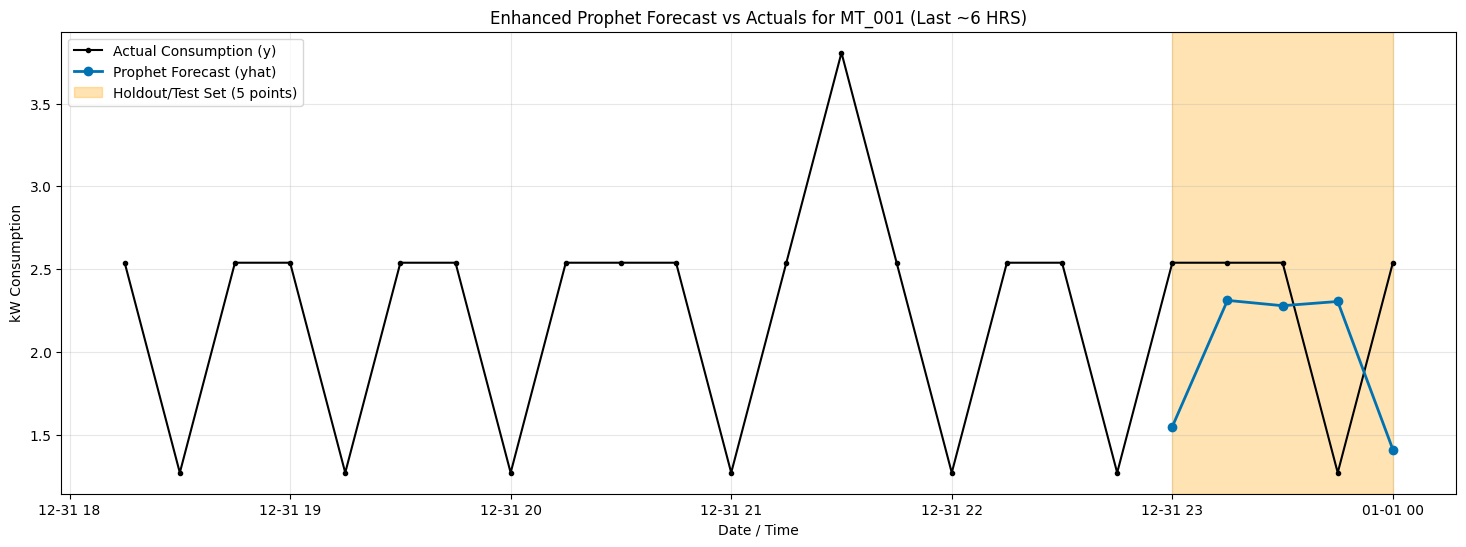

In [13]:
# ---------------------------------------------------------
# 5. Visualizations
# ---------------------------------------------------------
zoom_idx = -24

plt.figure(figsize=(18, 6))

# Plot the real data
plt.plot(client_df['ds'].iloc[zoom_idx:], client_df['y'].iloc[zoom_idx:], 
         label='Actual Consumption (y)', color='black', marker='.', linestyle='-')

# Plot the Prophet forecast
plt.plot(forecast['ds'], forecast['yhat'], 
         label='Prophet Forecast (yhat)', color='#0072B2', linewidth=2, marker='o')

# Highlight the 5-point holdout area
plt.axvspan(test_df['ds'].iloc[0], test_df['ds'].iloc[-1], 
            color='orange', alpha=0.3, label='Holdout/Test Set (5 points)')

plt.title(f'Enhanced Prophet Forecast vs Actuals for {client_id} (Last ~6 HRS)')
plt.xlabel('Date / Time')
plt.ylabel('kW Consumption')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

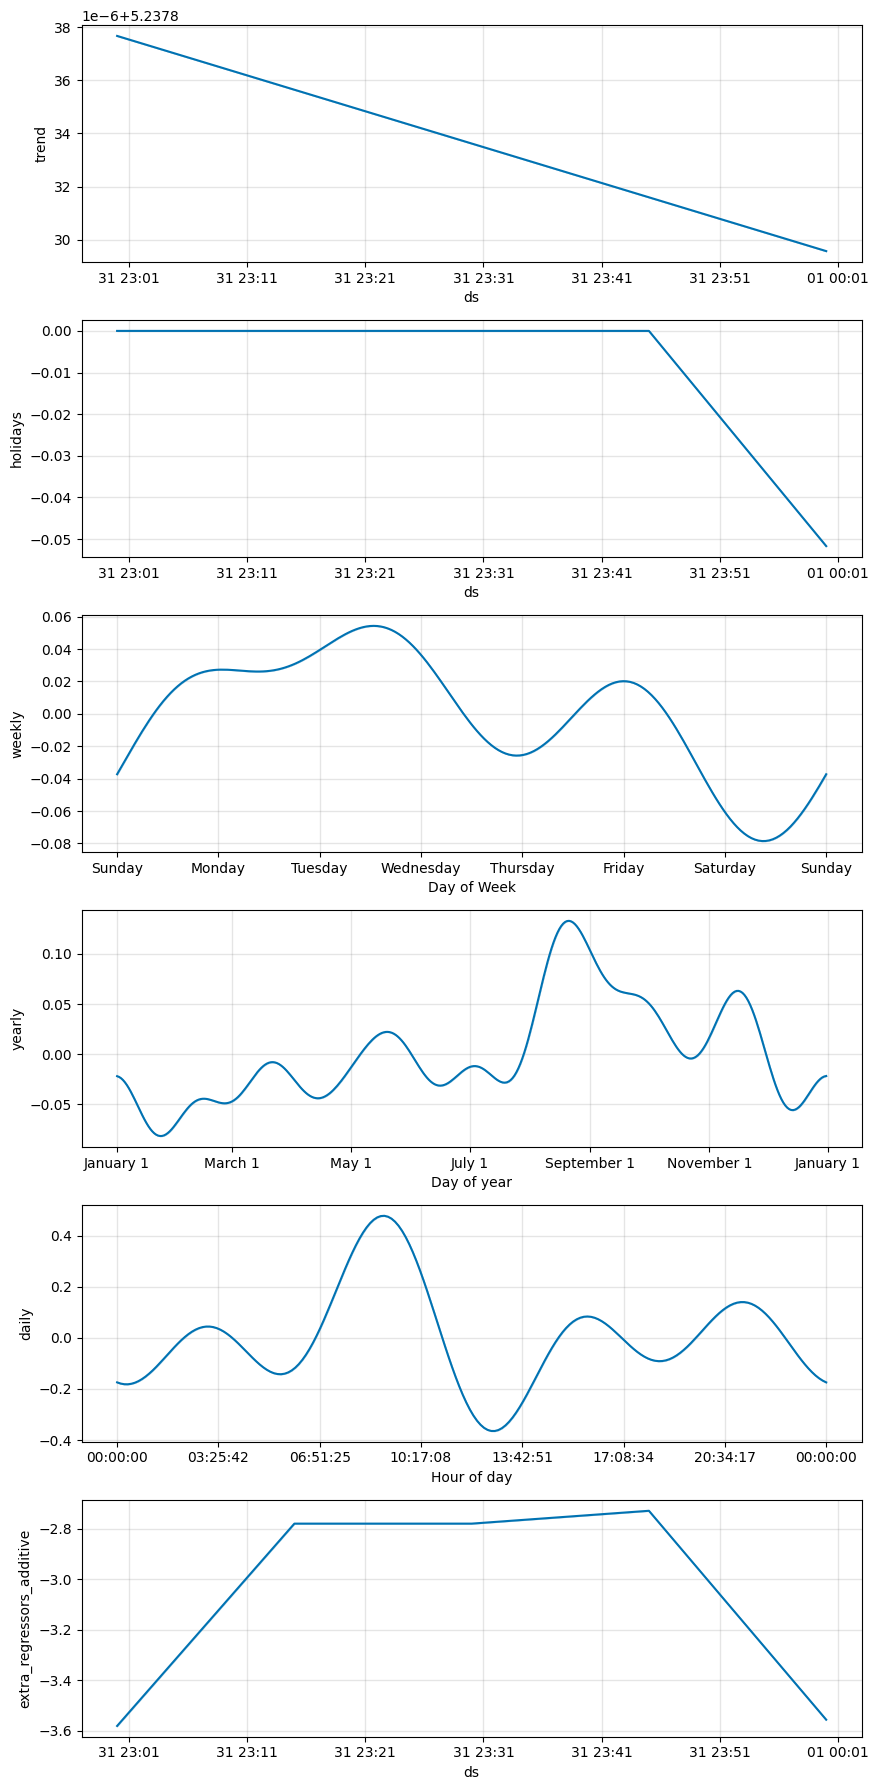

In [14]:
# PLOT B: Prophet Components
fig_components = m.plot_components(forecast)
plt.show()

Loading processed data...
Starting Prophet evaluation for 30 clients. This may take a few minutes...


Training Prophet Models:   0%|          | 0/30 [00:00<?, ?it/s]

17:42:40 - cmdstanpy - INFO - Chain [1] start processing
17:42:47 - cmdstanpy - INFO - Chain [1] done processing
17:42:51 - cmdstanpy - INFO - Chain [1] start processing
17:43:00 - cmdstanpy - INFO - Chain [1] done processing
17:43:04 - cmdstanpy - INFO - Chain [1] start processing
17:43:08 - cmdstanpy - INFO - Chain [1] done processing
17:43:12 - cmdstanpy - INFO - Chain [1] start processing
17:43:17 - cmdstanpy - INFO - Chain [1] done processing
17:43:21 - cmdstanpy - INFO - Chain [1] start processing
17:43:29 - cmdstanpy - INFO - Chain [1] done processing
17:43:30 - cmdstanpy - INFO - Chain [1] start processing
17:43:32 - cmdstanpy - INFO - Chain [1] done processing
17:43:36 - cmdstanpy - INFO - Chain [1] start processing
17:43:42 - cmdstanpy - INFO - Chain [1] done processing
17:43:46 - cmdstanpy - INFO - Chain [1] start processing
17:43:55 - cmdstanpy - INFO - Chain [1] done processing
17:43:59 - cmdstanpy - INFO - Chain [1] start processing
17:44:02 - cmdstanpy - INFO - Chain [1]



--- 30-CLIENT PROPHET BENCHMARK RESULTS ---
Average MAPE: 2573955534956583.50%
Average MAE:  16.12 kW
Average MSE:  1242.18
Average RMSE: 18.43 kW


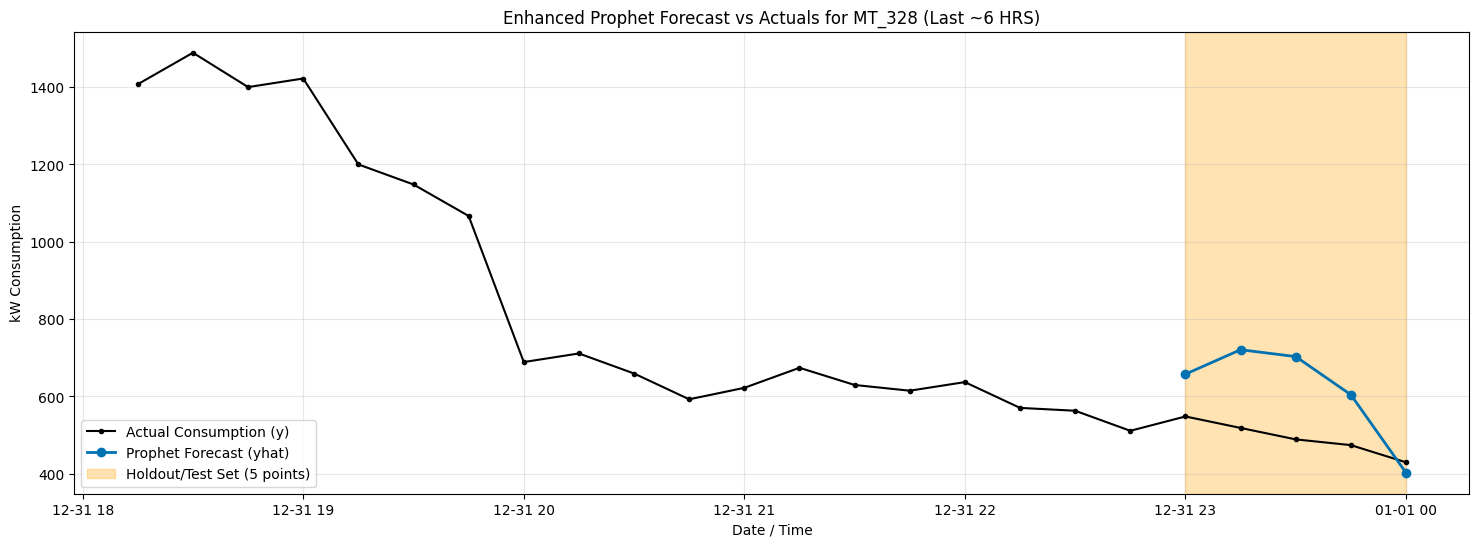

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
import logging
from prophet import Prophet
from sklearn.metrics import mean_absolute_percentage_error, mean_absolute_error, mean_squared_error

# Suppress Prophet's repetitive logging so it doesn't flood your notebook
logging.getLogger('cmdstanpy').setLevel(logging.WARNING)
pd.set_option('display.max_columns', None)

# ---------------------------------------------------------
# 1. Load Parquet & Replicate Teammate's Sample
# ---------------------------------------------------------
print("Loading processed data...")
df_long = pd.read_parquet('../Datasets/processed_electricity_data.parquet', engine='pyarrow')

# Use the EXACT same seed and sample as the Linear Regression notebook
random.seed(42)
all_clients = df_long['ClientID'].unique().tolist()
sampled_clients = random.sample(all_clients, 30)

print(f"Starting Prophet evaluation for {len(sampled_clients)} clients. This may take a few minutes...")

# ---------------------------------------------------------
# 2. Initialize Metric Trackers
# ---------------------------------------------------------
all_mapes = []
all_maes = []
all_mses = []
all_rmses = []

# We will save the first client's data specifically to plot it later
plot_data = {} 

# ---------------------------------------------------------
# 3. The Grand Prophet Loop
# ---------------------------------------------------------
for i, client_id in enumerate(tqdm(sampled_clients, desc="Training Prophet Models")):    
    # Isolate and prep client
    client_df = df_long[df_long['ClientID'] == client_id].copy()
    client_df = client_df.rename(columns={'Date': 'ds', 'Consumption': 'y'})
    client_df = client_df.sort_values('ds').reset_index(drop=True)

    # Time Series Split (Holdout Set)
    train_df = client_df.iloc[:-5]
    test_df = client_df.iloc[-5:]

    # Model Training
    m = Prophet()
    m.add_country_holidays(country_name='PT') 
    m.add_regressor('Temp_National_Avg')
    m.add_regressor('Lag_15min')
    m.add_regressor('Lag_24h')
    m.add_regressor('Rolling_Mean_4h')
    m.fit(train_df)

    # --- The Recursive Loop (No Leakage) ---
    future_steps = test_df[['ds', 'Temp_National_Avg']].copy().reset_index(drop=True)
    history_y = list(train_df['y'].values)
    clean_predictions = []

    for step in range(5):
        current_step = future_steps.iloc[[step]].copy()
        
        # Dynamically calculate the unsafe lags
        current_step['Lag_15min'] = history_y[-1] 
        current_step['Lag_24h'] = history_y[-96]             
        current_step['Rolling_Mean_4h'] = np.mean(history_y[-16:]) 
        
        step_forecast = m.predict(current_step)
        yhat = step_forecast['yhat'].values[0]
        
        clean_predictions.append(yhat)
        history_y.append(yhat)

    # Evaluation
    y_true = test_df['y'].values
    y_pred = np.array(clean_predictions)

    all_mapes.append(mean_absolute_percentage_error(y_true, y_pred))
    all_maes.append(mean_absolute_error(y_true, y_pred))
    all_mses.append(mean_squared_error(y_true, y_pred))
    all_rmses.append(np.sqrt(mean_squared_error(y_true, y_pred)))
    
    # Save the first client's data for our plot
    if i == 0:
        plot_data = {
            'client_id': client_id,
            'client_df': client_df,
            'test_df': test_df,
            'y_pred': y_pred
        }

print("\n\n--- 30-CLIENT PROPHET BENCHMARK RESULTS ---")
print(f"Average MAPE: {np.mean(all_mapes):.2%}")
print(f"Average MAE:  {np.mean(all_maes):.2f} kW")
print(f"Average MSE:  {np.mean(all_mses):.2f}")
print(f"Average RMSE: {np.mean(all_rmses):.2f} kW")

# ---------------------------------------------------------
# 4. Visualization (Plotting the exact same client as teammate)
# ---------------------------------------------------------
zoom_idx = -24

plt.figure(figsize=(18, 6))

# Plot the real historical data
plt.plot(plot_data['client_df']['ds'].iloc[zoom_idx:], plot_data['client_df']['y'].iloc[zoom_idx:], 
         label='Actual Consumption (y)', color='black', marker='.', linestyle='-')

# Plot the Prophet forecast (Fixed to use test dates and recursive predictions)
plt.plot(plot_data['test_df']['ds'], plot_data['y_pred'], 
         label='Prophet Forecast (yhat)', color='#0072B2', linewidth=2, marker='o')

# Highlight the 5-point holdout area
plt.axvspan(plot_data['test_df']['ds'].iloc[0], plot_data['test_df']['ds'].iloc[-1], 
            color='orange', alpha=0.3, label='Holdout/Test Set (5 points)')

plt.title(f"Enhanced Prophet Forecast vs Actuals for {plot_data['client_id']} (Last ~6 HRS)")
plt.xlabel('Date / Time')
plt.ylabel('kW Consumption')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()